# Notebook 4: Initial Modeling Assessment
Written By Kelly-Marie Yokuda for the BrainStation Capstone Project "Professor Power Index"

In [8]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, precision_score, accuracy_score

# Misc tools
from tqdm.notebook import tqdm
from tempfile import mkdtemp
import os
import inspect
import joblib
import warnings
warnings.filterwarnings("ignore")

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of scientific journals using co-author metrics alone. 

# Introduction

The objective of this notebook is to assess the efficacy of various classification models in categorizing citation entries based on the provided author metrics. Initially, we will analyze the performance of each model individually and explore opportunities for optimizing their performance. Subsequently, using the findings from these studies, we will perform a grid search for each model to determine which one performs the best overall based on the given scoring criteria.

#### Defining the Scoring Criteria
Here, we define the model's score as the model's accuracy score averaged with the model's weighted precision score where a higher average corresponds to a higher score.This custom score is deployed using function `custom_score`. This custom score was chosen so that the precision of the model would be equally weighed against its accuracy. As a result, we will have a model that correctly classifies the greatest citations (accuracy), while also ensuring that achieving the most number of correctly classified citations is not done at the expense of citations belonging to the minority classes being wrongfully classified (precision). We chose to assess the model on precision rather than recall or f1-score since the goal of our model is to minimize the number of false positives as much as possible, even if it means sacrificing some true positives or increasing the number of false negatives. Each calculation will be done using a 5-fold cross validation to account for the small data set size (< 16,000) unless otherwise stated.

In [9]:
ml_df = pd.read_pickle('output/NB3_ml_df.pkl')

`ml_df` is our data set for performing machine learning. Here the target column is `PubTier`, which is the tier that each citation is classified in, while the remaining statistics for the first, second and third authors are the features.

In [10]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   first_auth_Median_AuthorRank       14382 non-null  float16
 1   first_auth_Median_Cites            14382 non-null  float16
 2   first_auth_Median_Year             14382 non-null  float16
 3   first_auth_Median_GSRank           14382 non-null  float16
 4   first_auth_Median_AuthorCount      14382 non-null  float16
 5   first_auth_Author_Hindex           14382 non-null  int8   
 6   second_auth_Median_AuthorRank      14382 non-null  float16
 7   second_auth_Median_Cites           14382 non-null  float16
 8   second_auth_Median_Year            14382 non-null  float16
 9   second_auth_Median_GSRank          14382 non-null  float16
 10  second_auth_Median_AuthorCount     14382 non-null  float16
 11  second_auth_Author_Hindex          14382 non-null  int

We'll define the features and target column. Next, we'll split the data set so that 25% of the data set is saved for testing.

In [11]:
# Define features and target colums
X = ml_df.drop('PubTier', axis = 1)
y = ml_df['PubTier']

# Split the data set
X_remainder, X_test, y_remainder, y_test =  train_test_split(X, y, test_size=0.25, random_state = 1)

In [12]:
# Define a custom scoring function that combines accuracy and precision scores

def custom_score_func(y_val, y_pred):
    '''
    
    This function finds the average of the accuracy score and precision scores to use to find the best
    fitting model in GridSearchCV.
    
    Parameters:
    ---------
    y_val: list 
        Validation set of the input target data, used as the true values.
    y_pred: list
        Predicted labels returned by the classifer.
    
    Return:
    ------
    ret: The accuracy and precision score averaged.
    
    '''
    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    return (acc + precision) / 2

custom_score = make_scorer(custom_score_func, greater_is_better = True)

In [13]:
def update_params(func, params):
    
    '''
    Update function parameters with the provided dictionary of parameters.
    
    Parameters:
    ---------
    func: func 
        function object
    params: dict 
        A dictionary containing parameter names and values
    
    Returns:
    -------
    ret: The updated function
    '''
    
    assert isinstance(params, dict), 'Input params must be a dictionary'
    
    bound_args = inspect.signature(func).bind(**params)  # bind the arguments to the function parameters
    bound_args.apply_defaults()  # use default values for any unspecified parameters
    
    return func(*bound_args.args, **bound_args.kwargs)  # call the function with the updated parameters

def get_scores(model_obj, decomp_obj = None, add_test = False):
    
    '''
    Compute performance scores for a given classification model object with optional PCA dimensionality reduction.
    
    Parameters:
    ----------
    model_obj:  
        classification model object with a predict_proba method
    decomp_obj: (default=None)
        PCA object for dimensionality reduction 
    add_test: str (default=False)
        whether or not to compute scores on a test set 
    
    Returns:
    ret: dict
        A dictionary of performance scores for training and validation sets (and test set if add_test=True).
    '''

    # Make sure the model_obj is a classifcation model_obj by checking for the presence of a method
    assert hasattr(model_obj, 'predict_proba'), "Input model_obj is not a classification model_obj"
   
    # Inititate Dictionary
    dic = {'Accuracy Score':{}, 'Weighted Precision Score': {}, 'Custom Score': {}}
    
    #we give our estimators as a list of tuples
    
    if decomp_obj != None:
        
        # Make sure the decomp_obj is a classifcation model_obj by checking for the presence of a method
        assert isinstance(decomp_obj, PCA), "Input decomp_obj is not a PCA obj"
        
        estimators = [('normalise', StandardScaler()), # scalar
                      ('scalar', decomp_obj), # dimentionality reduction 
                      ('model_obj', model_obj)] # fit to model_obj
    elif decomp_obj == None:
        estimators = [('normalise', StandardScaler()), # scalar
                      ('model_obj', model_obj)] # fit to model_obj
        
    # Initiate Pipeline
    #cachedir = mkdtemp(dir = r'D:\Git\tmp')
    #pipe = Pipeline(estimators, memory = cachedir)
    pipe = Pipeline(estimators)

    # Fit to model_obj
    pipe.fit(X_remainder, y_remainder)
    
    # Do Cross-Validation for 5 folds and return the scores

    # Accuracy Scores
    cvs_acc = cross_validate(pipe, X_remainder, y_remainder, cv = 5, return_train_score=True) 

    # Precision Scores
    cvs_pre = cross_validate(pipe, X_remainder, y_remainder, cv = 5, scoring='precision_weighted', return_train_score=True)

    # Custom Scores
    cvs_cust = cross_validate(pipe, X_remainder, y_remainder, cv = 5, scoring=custom_score, return_train_score=True)
    
    
    # Add values to dictionary
    dic['Accuracy Score']['Training'] = np.mean(cvs_acc['train_score'])
    dic['Accuracy Score']['Validation'] = np.mean(cvs_acc['test_score'])
    dic['Custom Score']['Training'] = np.mean(cvs_cust['train_score'])
    dic['Custom Score']['Validation'] = np.mean(cvs_cust['test_score'])
    dic['Weighted Precision Score']['Training'] = np.mean(cvs_pre['train_score'])
    dic['Weighted Precision Score']['Validation'] = np.mean(cvs_pre['test_score'])
    
    if add_test == True:
        
        # Initiate the predicted classifcations
        y_pred = pipe.predict(X_test)
        
        # add to dictionary
        dic['Accuracy Score']['Test'] = accuracy_score(y_test, y_pred)
        dic['Custom Score']['Test'] = custom_score_func(y_test, y_pred)
        dic['Weighted Precision Score']['Test'] = precision_score(y_test, y_pred, average='weighted')
        
    return dic

def decomp_fit(decomp_obj):

    # Make sure the decomp_obj is a classifcation model_obj by checking for the presence of a method
    assert isinstance(decomp_obj, PCA), "Input decomp_obj is not a PCA obj"

    estimators = [('normalise', StandardScaler()), # scalar
                  ('scalar', decomp_obj)] # dimentionality reduction
    
    # Initiate Pipeline
    pipe = Pipeline(estimators)
    
    # Fit the pipeline
    pipe.fit(X_remainder, y_remainder)

    # Use 5-fold cross-validation to evaluate the pipeline's performance
    scores = cross_val_score(pipe, X_remainder, y_remainder, cv=5)

    return pipe.named_steps['scalar']

In [14]:
color_pal = sns.color_palette("Set2")

class score_models:
    
    '''
    
     A class for scoring and plotting classification model results.
    
    '''
    
    def __init__(self, model_obj, decomp_obj = None, model_param = None, model_name = '', add_test = False):
        
        '''
        
        Initiates and instance of score_models
        
        Parameters:
        -----------
        model_obj: object
            A classification model object with a predict_proba method. 
            
        decomp_obj: PCA object or None (default=None)
            A PCA object for decomposition of features before modeling.
        
        model_param: dictionary or None (default=None)
            A dictionary of hyperparameters to update in the model object.
        
        model_name: str (default='')
            A string for naming the model instance.
        
        add_test: bool (default=False)
            A boolean for including a test set score in the scoring results.
        
        Return:
        ------
        ret: None
        
        '''
        
        
        
        self.model_name = model_name
        self.model_param = model_param
        self.add_test = add_test

        # Make sure the model_obj is a classifcation model_obj by checking for the presence of a method
        assert hasattr(model_obj, 'predict_proba'), "Input model_obj is not a classification model_obj"
        
        if decomp_obj != None:
            # Make sure the decomp_obj is a classifcation model_obj by checking for the presence of a method
            assert isinstance(decomp_obj, PCA), "Input decomp_obj is not a PCA obj"
        
        self.model_obj = model_obj
        self.decomp_obj = decomp_obj
        self.model_inst = update_params(self.model_obj, self.model_param)
        self.score_dic = get_scores(self.model_inst, self.decomp_obj, add_test = self.add_test)
        self.search_dic = None
        
    def set_decomp_obj(self, new_decomp_obj):
        
        '''
        Updates the decomposition object (PCA Object) for the model.
        
        Parameters:
        -----------
        self: Object
            The instance of score_method  
        new_decomp_obj: PCA object
            A new PCA object for decomposition of features before modeling.
        
        Return:
        ------
        ret: None
        '''
        
        assert isinstance(new_decomp_obj, PCA), "Input decomp_obj is not a PCA obj"
        
        self.decomp_obj = new_decomp_obj

    def plt_scores(self):
        
        
        '''
        A method for plotting the model scores.
        
        Paramerters:
        -----------
        self: Object
            The instance of score_method  
        
        Returns:
        --------
        fig: matplotlib.figure.Figure
            A figure instance of the plot.
        '''
        
        
        assert self.score_dic != None, 'Instance Must be Scored Before Plotted'
        
        plt.ioff() # figures will not automatically be shown
        dic = self.score_dic
        fig = plt.figure()
        ax = fig.subplots(1,1)
        
        j = 0
        for key in list(dic.keys()):
            for sub_key in list(dic[key]):
                bar_height = dic[key][sub_key]
                
                if sub_key == 'Training':
                    c = color_pal[0]
                elif sub_key == 'Validation':
                    c = color_pal[1]
                elif sub_key == 'Test':
                    c = color_pal[2]
                ax.bar(j, bar_height, width = 0.25 , label = sub_key, color = c)

                
                # Setting the distnance between bars
                if self.add_test == True:
                    j += 0.40
                elif self.add_test == False:
                    j += 0.35
                    
            j += 0.5
        
        
        ax.set_ylim([0.6, 0.85])
        ax.set_ylabel('Model Accuracy')
        ax.set_title(f'Results of {self.model_name} Default Parameter Fit')
        h, l = ax.get_legend_handles_labels()
        
        
        # Determine the number of x-ticks and legend handles based off of if the Test bars will be included
        if self.add_test == True:
            x_ticks = np.arange(0.4, 4, 1.7)
            ax.legend(h[:3], l[:3], title = 'Set Type')
        elif self.add_test == False:
            x_ticks = np.arange(0.175, 3.175, 1.2)
            ax.legend(h[:2], l[:2], title = 'Set Type')
            
        ax.set_xticks(x_ticks, list(dic.keys()))
        ax.set_yticks([],[])
        
        return fig
    
    
    def plt_hp_opt(self):
        
        '''
        A method for plotting the hyper-parameter optimization results
        
        Paramerters:
        -----------
        self: Object
            The instance of score_method  
        
        Returns:
        --------
        fig: matplotlib.figure.Figure
            A figure instance of the plot.
        '''
        
        
        assert self.search_dic != None, 'Parameter Search Must be Carried Before Plotting'
        
        dic = self.search_dic
        fig = plt.figure()
        ax = fig.subplots(1,1)
        ax.grid()

        # Name of the parameter being optimized
        param_name = dic['ParameterName']

        # Values for the x-axis
        x = dic['ParameterValues']

        # Plotting Average Accuracy Scores
        j = 0
        for key in list(dic.keys())[:2]:
            y = dic[key]
            c = color_pal[j]
            ax.plot(x, y, color = c, marker = '.', label = key)
            j += 1
            
        ax.set_xlabel(f'Values of {param_name}')
        
        y_ticks = np.arange(0.1, 1.02, 0.01)
        y_labels = ['{:.0%}'.format(i) for i in y_ticks]
        ax.set_yticks(y_ticks, y_labels)

        ax.set_ylabel('Model Accuracy')
        ax.set_ylim([0.6, 0.8])
        ax.set_title(f'{self.model_name} Hyperparameter Optimization')
        ax.legend();
        
        return fig
        
            
    def search(self, param_key, param_arr):
        
        '''
        A method for performing hyper-paramter optimization searches
        
        Paramerters:
        -----------
        self: Object
            The instance of score_method
        param_key: str
            The parameter to change 
        param_key: list of np.array
            An arrary of possible parameter values to test against.
        
        Returns:
        --------
        ret: None
        
        '''
        assert isinstance(param_key, str), 'Parameter Key Must be String'
        
        # Initiating the dictionary to store results
        dic = {'Training Score':[], 'Validation Score': [], 'ParameterValues': param_arr, 'ParameterName': str}
        
        # Storing the name of the optimized parameter
        dic['ParameterName'] = param_key
        
        # Looping over parameter values
        for param_val in tqdm(param_arr):
            
            # Create a copy of the model_param dictionary 
            param_dic = self.model_param.copy()
            
            # replacing parameter dictionary with updated value
            param_dic[param_key] = param_val
            
            # Defining the new model using the updated parameters
            new_model = update_params(self.model_obj, param_dic)
            
            # scoring the new model
            self.score_dic = get_scores(new_model, self.decomp_obj)
            
            dic['Training Score'].append(self.score_dic['Accuracy Score']['Training'])
            dic['Validation Score'].append(self.score_dic['Accuracy Score']['Validation'])

        self.search_dic = dic

## Model 1: Logistic Regression

### Initial Model Fitting
We will fit a logistic regression model to our data using default hyper-parameter settings in order to establish a baseline for training and validation accuracy, precision metrics, as well as the custom score.

In [15]:
model_obj = LogisticRegression
sm_logreg = score_models(model_obj, model_param = {'solver':'lbfgs', 'random_state': 1, 'C':1}, model_name = 'LogReg')

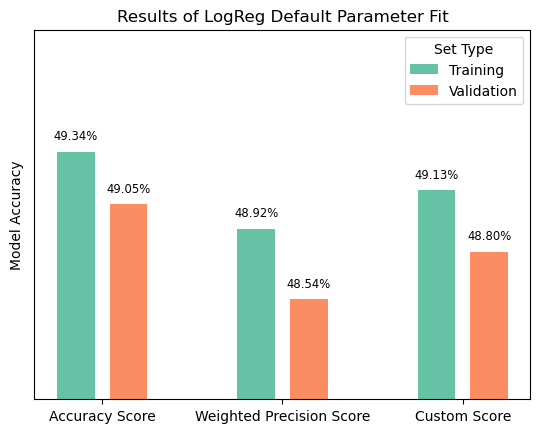

In [16]:
sm_logreg.plt_scores();
plt.ylim([0.48, 0.50]);
plt.show()

If we were to randomly guess the classification of each observation, we could do so with 33% accuracy. Therefore, from the training accuracy score and validation accuracy score being around 50%, the logistic regression model fitting results that the model's classification accuracy is only slightly better than random guessing. Additionally, the weighted precision scores for both the training and validation data are near 50%, indicating that the model is not proficient in identifying positive cases for any of the three classes. These results are also reflected in the custom score that is also near 52%., which also suggests that the custom score is doing its job at averaging the accuracy and precisions scores.  Overall, These results suggest that the current model may not be sufficiently generalizable and may not perform well on new data, so further investigation into improving the model's accuracy should be performed.

### Optimizing Model Accuracy

#### Part 1: Addressing Multicollinearity
Since logistic regression is a linear classification model, before perform considering the landscape of hyper-parameters to increase model accuracy, we should first access the other potential issues that could hinder the accuracy of the model, such as multicollinearity.

We can investigate multicollinearities between features using a heat map.

In [17]:
ml_corr = ml_df.drop('PubTier', axis = 1).corr()

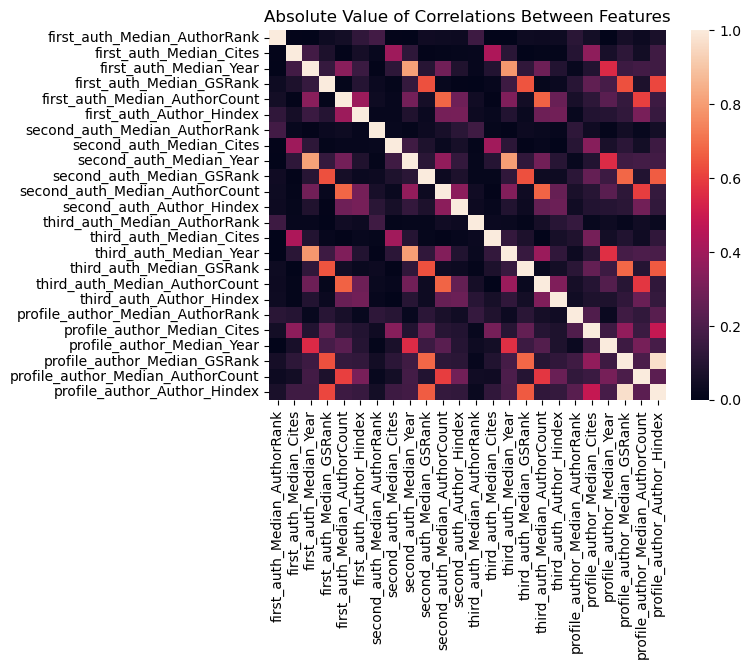

In [18]:
sns.heatmap(np.abs(ml_corr), vmin = 0, vmax = 1)
plt.title('Absolute Value of Correlations Between Features')
plt.show()

From the heatmap, we see that there are areas where collinearity between features is strong, i.e., > 0.5. Let's rescale the heatmap to highlight those collinearities.

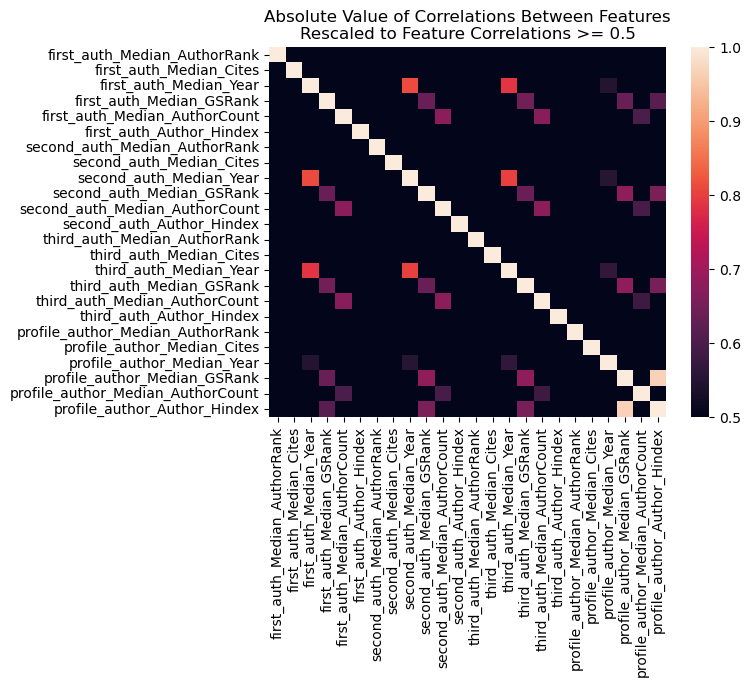

In [19]:
sns.heatmap(np.abs(ml_corr), vmin = 0.5, vmax = 1)
plt.title('Absolute Value of Correlations Between Features\nRescaled to Feature Correlations >= 0.5')
plt.show()

From this rescaled heat map, we see that most of the features have a correlation to another feature that has an absolute value over 0.5, with some features have correlations to another feature with a value over 0.8. Since our data set has < 50 features and most of the features attributes to the multicollinearity, removing select features through feature selection is unlikely going to solve multicollinearity issue. Instead, removing what limited features the model does have could result in the model being less generalizable if the limited columns selected do not adequately capture the variance in the data set. Overall, given the wide-spread multicollinearity and limited number of features, pursuing logistic regression as our classification model may not be ideal. 

However, we could employ a method of dimensionality reduction, such as principal vector component analysis (PCA) to reduce the number of columns, which could reduce multicollinearity, while preserving the variance in the data set. The effectiveness of PCA at capturing the variance of the data set can be quantified using the *explained variance ratio* for each of principle component (PC) describe the variation in the data set. Specifically, the explained variance ratio describes the *percentage* of the variance that each PC is able to account for, with the goal of increasing the number of PCs until all the variance in the data set can be adequately captured.

We can identify the number of PCs that adequately capture the variance in our data set by making a line plot of the explained variance ratios and identifying the elbow in the plot to decide how many PCs are  adequate. The number of PCs at the elbow in the plot will identify the threshold for where any additional PCs will not substantially raise the explained variance, and are therefore redundant at explaining the variance in the data set.

The number of PCs can be controlled using the `n_components` hyper-parameter. Let's examine how the number of principal components by examining the *explained variance ratios* for each.

In [21]:
n_list = np.arange(2, 25, 4)
EVR_list = []

for n in tqdm(n_list):
    # Initiate PCA Model
    my_PCA = PCA(n_components = n)
    
    # Fit to data set
    fit_obj = decomp_fit(my_PCA)
    
    EVR = fit_obj.explained_variance_ratio_.mean()
    EVR_list.append(EVR)

  0%|          | 0/6 [00:00<?, ?it/s]

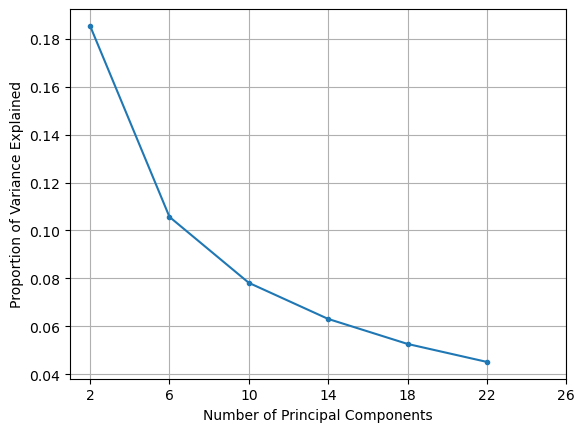

In [22]:
plt.plot(n_list, EVR_list, marker = '.')
plt.xlabel('Number of Principal Components')
plt.ylabel('Proportion of Variance Explained')
plt.grid()
x_ticks = np.arange(2, 30, 4)
plt.xticks(x_ticks, x_ticks);
plt.show()

Here we see that the elbow in the plot is between 6-10 PCs suggesting that any additional PCs added beyond that will not substantially raise the explained variance. Additionally, it appears that the explained variance ratio does not truly become constant as the number of principal components approaches the maximum number of columns in the data set (37), suggesting that the features are very co-linear and that PCA is necessary to reduce collinearity. Let's look at a heat map of the PCA components for `n_components` = 6 and `n_components` = 10 to how the collinearity changes after appplying PCA.

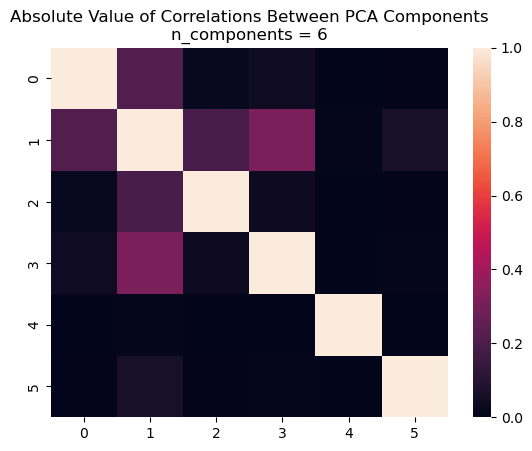

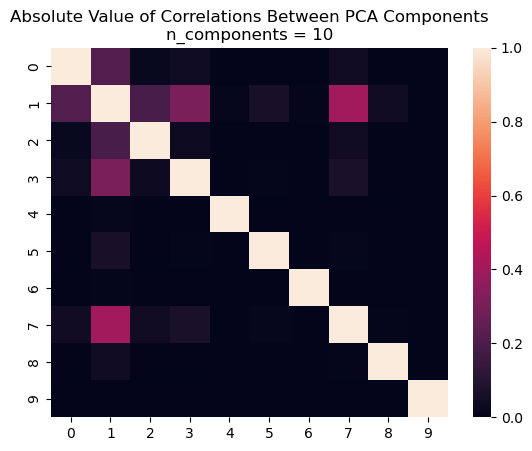

In [23]:
for i in [6, 10]:
    # Initiate PCA Model
    my_PCA = PCA(n_components = i)
    
    # Fit to data set
    fit_obj = decomp_fit(my_PCA)

    # Converting to DF to get correlation matrix. Transposing the array so that components are the columns.
    pca_corr = pd.DataFrame(my_PCA.components_.T).corr()

    sns.heatmap(np.abs(pca_corr), vmin = 0, vmax = 1)
    plt.title(f'Absolute Value of Correlations Between PCA Components\nn_components = {i}')
    plt.show()

From these results we observe that there are no longer any columns that have a correlation of > 0.5 for both the lower bound of `n_components` = 6 and upper bound of `n_components` = 10. These results suggests that any number of components between 6 and 30 selected by the grid search would not result in features that have strong correlations in between them, therefore suggesting the logistic regression could still be a feasible model for the data set when PCA in employed.

In [24]:
model_obj = LogisticRegression
sm_logreg_pca = score_models(model_obj, PCA(n_components = 7), model_param = {'solver':'lbfgs', 'random_state': 1, 'C':1}, model_name = 'LogReg')

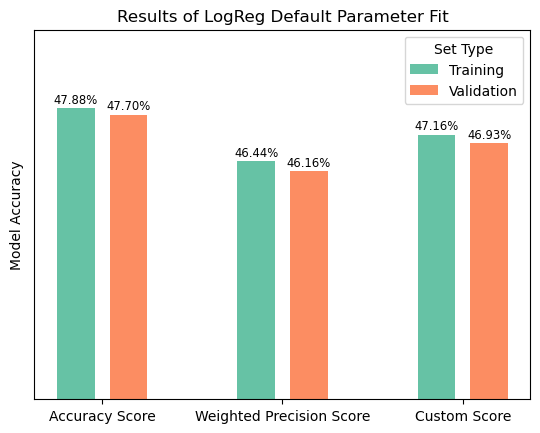

In [25]:
sm_logreg_pca.plt_scores();
plt.ylim([0.40, 0.50]);
plt.show()

Comparing the performance of the logistic regression model before and after applying PCA, we observe that the accuracy and precision scores have decreased after employing PCA. Before PCA, the model had a training and validation accuracy score of 
near 52%, while after PCA, the model's training and validation accuracy score dropped to near 51%. Similarly, the weighted precision score and custom score for the training and validation data also decreased after PCA. These results suggest that applying PCA has not improved the performance of the logistic regression model in terms of accuracy and precision but rather slightly reduced the model's performance. However, we should still employ PCA into the logistic regression model to reduce multicollinearity.

#### Part 2: Optimizing Hyper Parameters

Using the PCA to remove multicoliinearity with `n_components` = 7, we can optimize the hyper-parameter `C` in the logistic regression model in order to optimize the weight of the cost function. Let's examine how the training and testing accuracy changes for values of `C` over a large range ($10^{-5},10^{5}$).

In [28]:
c_vals = np.asarray([10**i for i in range(-5, 5)])
sm_logreg_pca.search('C', c_vals)

  0%|          | 0/10 [00:00<?, ?it/s]

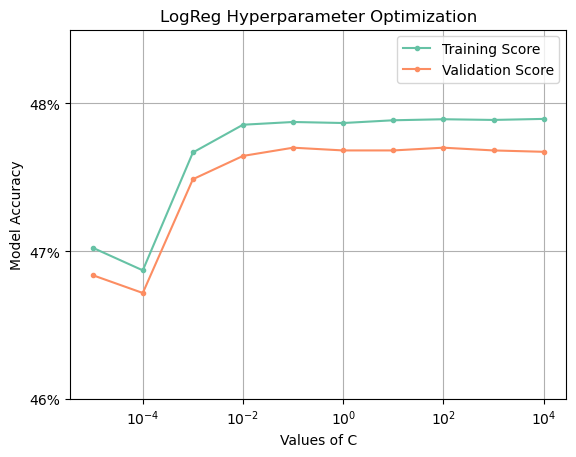

In [31]:
fig = sm_logreg_pca.plt_hp_opt();
ax, = fig.get_axes();
ax.set_xscale('log');
ax.set_yticks(np.arange(0.1, 1, 0.01), ['{:.0%}'.format(i) for i in np.arange(0.1, 1, 0.01)]);
ax.set_ylim([0.46, 0.485]);
plt.show()

Based on the results, we can infer that the C parameter significantly affects the training and validation accuracy until it reaches a value of $10^{-2}$, after which the accuracy stabilizes but with a slight indication of overfitting. However, the extent of overfitting is less than 1%, which implies that choosing a value for `C` $> 10^{-2}$ might be more appropriate. Despite this, the overall accuracy for both training and validation sets is still low (51%), which suggests that the dataset might not contain enough information to make accurate predictions. Therefore, it may be beneficial to try a different model to see if the results can be improved.

---

## Model 2: KNN Classifers

### Initial Fitting
We will fit a K nearest-neightbor (KNN) model to our data using default hyper-parameter settings in order to establish a baseline for training and validation accuracy, precision metrics, as well as the custom score.

In [32]:
model_obj = KNeighborsClassifier
sm_knn = score_models(model_obj, model_param = {'n_neighbors':5}, model_name = 'KNN')

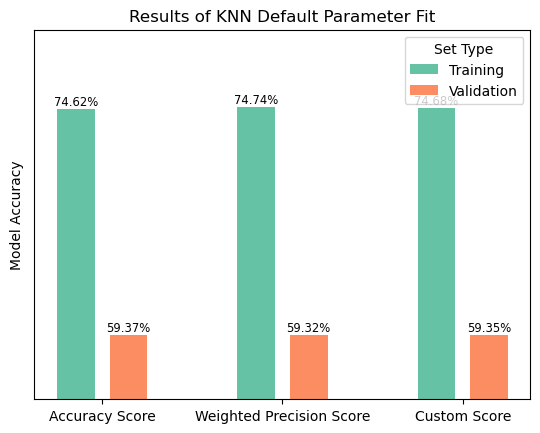

In [33]:
sm_knn.plt_scores();
plt.ylim([0.55, 0.80]);
plt.show()

When using the default hyper-parameter settings with `n_neighbors` set to 5, KNN performed similarly to logistic regression with the training accuracy score being close to 57% and the validation accuracy score around 50%. However, the larger gap between the training and validation accuracy scores indicates that KNN may be less generalizable than logistic regression and more prone to overfitting. This is supported by the similar training and validation scores for weighted precision and custom scores. Therefore, to increase the accuracy and precision of the model, a possible method is to use PCA, as was done for logistic regression. Let's attempt to improve the performance of the KNN model using PCA.

In [34]:
model_obj = KNeighborsClassifier
sm_knn_pca = score_models(model_obj, PCA(n_components=7), model_param = {'n_neighbors':5}, model_name = 'KNN')

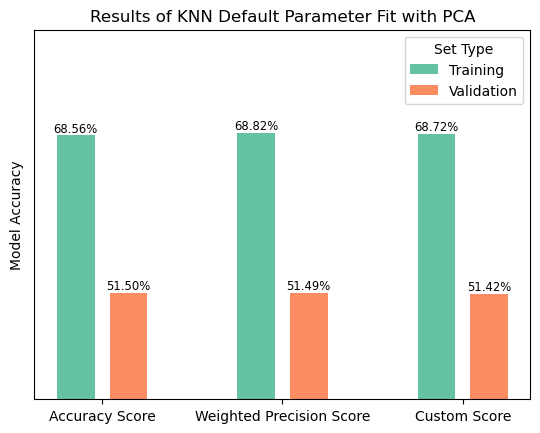

In [35]:
sm_knn_pca.plt_scores();
plt.title('Results of KNN Default Parameter Fit with PCA');
plt.ylim([0.4, 0.80]);
plt.show()

After applying PCA to the KNN model, the training accuracy and precision scores increased from 56% to nearly 65%, indicating that the model has become more accurate. However, the validation scores decreased from 50% to approximately 49%, suggesting that the increased training accuracy came at the cost of reduced generalizability. To address this issue, let's perform hyper-parameter optimization on `n_neighbors`.

### Optimizing Model Accuracy

Since we've employed PCA to our KNN model with `n_componts` = 7, let's see the model accuracy for KNN changes with integer step-size values of `n_neighbors` over a range of 1 to 7.

In [36]:
n_neigh_list = np.arange(1,7,1)
sm_knn_pca.search('n_neighbors', n_neigh_list)

  0%|          | 0/6 [00:00<?, ?it/s]

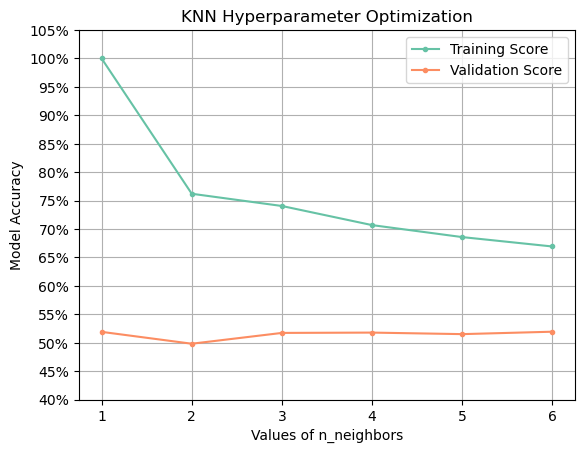

In [38]:
fig = sm_knn_pca.plt_hp_opt();
plt.yticks(np.arange(0.1, 1.1, 0.05), ['{:.0%}'.format(i) for i in np.arange(0.1, 1.1, 0.05)]);
plt.ylim([0.40, 1.05]);
plt.show()

From these results, we can conclude that the KNN model is overfitting the training data when n_neighbors is set to 1, as evidenced by the large gap between the training and validation accuracy scores. As n_neighbors increases, the model becomes less prone to overfitting and the training and validation accuracy scores begin to converge. However, the overall accuracy of the model remains relatively low, with a maximum validation accuracy of 50%. These results suggest that the KNN model may not be the best choice for this particular dataset. It also adds to the suspition that the dataset itself may not have enough sufficient information to accurately predict the target variable. Let's try a different model to see if the results can be improved.

---

## Model 3: Decision Tree

### Initial Fitting

We will fit a Decision Tree model to our data using default hyper-parameter settings in order to establish a baseline for training and validation accuracy, precision metrics, as well as the custom score.

In [39]:
model_obj = DecisionTreeClassifier
sm_dt = score_models(model_obj, model_param = {'min_samples_split':2}, model_name = 'DecisionTree')

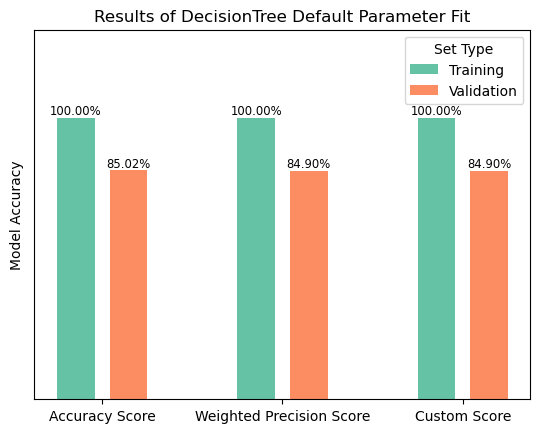

In [40]:
sm_dt.plt_scores();
plt.ylim([0.2, 1.25]);
plt.show()

With the default hyper-parameter settings (`max_depth`= None, `min_samples_split` = 2) we see that the decision tree model has a training accuracy score of near 70% and a validation accuracy score of near 50%, suggesting that the model is overfitting. Additionally, the precision scores on both training and validation data are also similar, further supporting this conclusion. To address this issue, let's perform hyper-parameter optimization on `max_depth` and `min_samples_split`.

### Optimizing Model Accuracy

To access how the model accuracy for decision trees changes with hyper-parameter optimization, let's observe how the model accuracy changes with integer step-sizes of `max_depth`. Here, the `max_depth` parameter will control for the number of nodes the decision tree can produce, which could result in the model over fitting to the trianing set if left too high. In its default state, the `max_depth` was set to `None` which left the termination to the node production to the defualt `min_samples_split` parameter, which defined how many observations were required to be categorized in a node for it to split.

In [41]:
md_list = np.arange(5, 32, 2)
sm_dt.search('max_depth', md_list)

  0%|          | 0/14 [00:00<?, ?it/s]

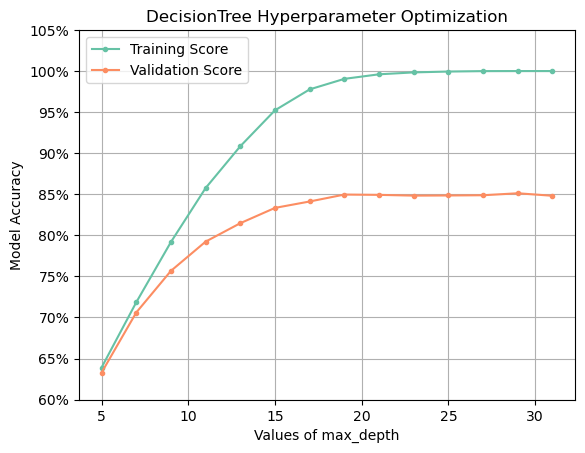

In [42]:
fig = sm_dt.plt_hp_opt();
ax, = fig.get_axes();
ax.set_yticks(np.arange(0.1, 1.1, 0.05), ['{:.0%}'.format(i) for i in np.arange(0.1, 1.1, 0.05)]);
ax.set_ylim([0.6, 1.05]);
plt.show()

The results of the `max_depth` optimization suggest that the model is most accurate and generalizable when `max_depth` is less than 7. Specifically, when `max_depth` is greater than 7, the training and validation scores start to diverge and the model becomes overfit to the training data, resulting in a training accuracy of 100% and validation accuracy of 45%. Therefore, increasing `max_depth` leads to overfitting, and the ideal parameter value for max_depth is below 7. Next, let's examine the results of fitting to `min_samples_split`.

In [43]:
ss_list = np.arange(2, 42, 2)
sm_dt.search('min_samples_split', ss_list)

  0%|          | 0/20 [00:00<?, ?it/s]

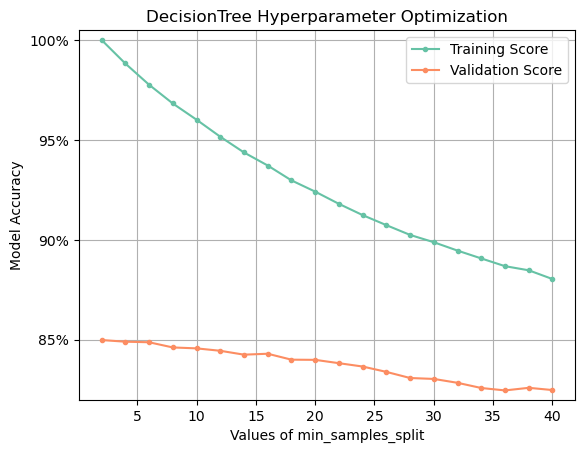

In [45]:
fig = sm_dt.plt_hp_opt();
ax, = fig.get_axes();
ax.set_yticks(np.arange(0.1, 1.1, 0.05), ['{:.0%}'.format(i) for i in np.arange(0.1, 1.1, 0.05)]);
ax.set_ylim([0.82, 1.005]);
plt.show()

The results of the `max_depth` optimization suggest that the model is most accurate and generalizable when `min_samples_split` is above 30. Specifically, when `min_samples_split` is greater than below 30, the training and validation scores diverge and the model becomes overfit to the training data, resulting in a training accuracy of 100% and validation accuracy of 45%. At `min_samples_split` values above 30, the validation scores stabilize near 50% and the training scores stabilize near 70%. This 20% difference between the training and validation scores near the ideal parameter compared to the < 5% difference in training and accuracy scores near the ideal `max_depth` parameter suggests that `max_depth` is the ideal parameter to optimize for maximizing generalizability. However,  the near 50% accuracy still raises suspicion that the dataset itself may not have sufficient information to accurately predict the target variable. Let's try an ensemble version of decision trees to see if the accuracies can be improved.

##  Model 4: Random Forest Model

### Initial Fitting

Let's try to fit a random forest model to see if bootstrapping and aggregating will improve the accuracy of the decision tree model. We will fit the random forest model to our data using default hyper-parameter settings in order to establish a baseline for training and validation accuracy, precision metrics, as well as the custom score.

In [46]:
model_obj = RandomForestClassifier
sm_rf = score_models(model_obj, model_param = {'n_estimators': 100}, model_name = 'RandomForest')

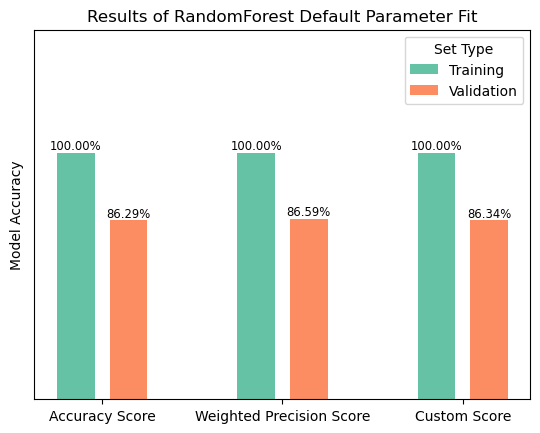

In [48]:
sm_rf.plt_scores();
plt.ylim([0.5, 1.25]);
plt.show()

With the default hyper-parameter settings (`n_estimators` = 100) and `max_depth` = 7, we see that the random forest model has a perfect training accuracy score of near 100% and a validation accuracy score of near 55%, suggesting that the model is overfitting. Additionally, the precision scores on both training and validation data are also similar, further supporting this conclusion. To address this issue, let's perform hyper-parameter optimization on `n_estimators`.

### Optimizing Model Accuracy

Let's access how the model accuracy for the random forest model changes with optimization using large integer step-sizes of `n_estimators` between 10 and 1,000.

In [49]:
es_list = np.arange(10, 500, 50)
sm_rf.search('n_estimators', es_list)

  0%|          | 0/10 [00:00<?, ?it/s]

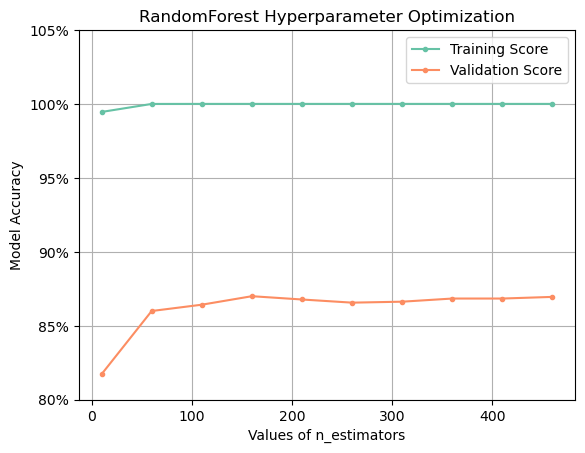

In [52]:
fig = sm_rf.plt_hp_opt();
ax, = fig.get_axes();
ax.set_yticks(np.arange(0.1, 1.1, 0.05), ['{:.0%}'.format(i) for i in np.arange(0.1, 1.1, 0.05)]);
ax.set_ylim([0.8, 1.05]);
plt.show()

From these results of the `n_estimators` optimization, we found that the difference between the training and validation scores and the absolute training and validation scores are not sensitive to the `n_estimators` parameter. Specifically, we see that the training and validation accuracy scores stay within 95-100% and 50-55%, respectively. Therefore, optimizing on the `n_estimators` parameter won't increase the validation accuracy or generalizability. However, also optimizing along the `max_depth` parameters could help the model's generalizability, as demonstrated in the decision tree model. Therefore, both parameters should be employed in further random forest optimization. 

## Choosing the Best Models for Grid Search

To assess the performance of the models with their optimal parameters, a grid search will be performed on each model. The results will be compared based on their validation accuracy, weighted validation precision score, and custom score. Here are the models we will evaluate and the parameters that they will be optimized on:

- Logistic Regression (LogReg) w/ PCA Decomposition 
    - `C`
    
    - `n_components` (for PCA)
- K Nearest-Neighbors (KNN) w/ PCA Decomposition 
    - `n_neighbors`
    
    - `n_components` (for PCA)
- Decision Tree
    - `max_depth`
- Random Forest
    - `n_estimators`
    
    - `max_depth`

Let's run the grid search on each of the models.

In [59]:
#Define estimators

estimators = [
    ('scalar', StandardScaler()),
    ('decomp', PCA()),
    ('model', DecisionTreeClassifier())]

c_vals = np.arange(0.1, 1, 0.2)
n_comp_vals = np.arange(6, 10, 1)
depth_vals = np.arange(5, 10, 1)
n_est_vals = np.arange(100, 220, 20)
n_est_vals = np.arange(100, 220, 20)
n_neightbors = np.arange(1, 10, 1)

# Initiate Pipeline object
cachedir = mkdtemp(dir = r'D:\Git\tmp')
pipe = Pipeline(estimators, memory = cachedir)

In [61]:
## Random forest

# Define parameter grid for grid search
param_grid = [
    {'model': [RandomForestClassifier()],
     'scalar':[StandardScaler()],
     'model__n_estimators': n_est_vals,
     'model__max_depth': depth_vals}]

# Initiate the GridSearchCV object with a 5-fold cross validation
rf_grid = GridSearchCV(pipe, param_grid=param_grid, cv = 5, scoring=custom_score)

# Perform the grid search, fitting the grid search to the training data only
rf_grid.fit(X_remainder, y_remainder)

#save your model or results
joblib.dump(rf_grid, 'rf_BestModel_V04-12.pkl')

['rf_BestModel_V04-12.pkl']

In [62]:
## Decision Tree

# Define parameter grid for grid search
param_grid = [
    {'model': [DecisionTreeClassifier()],
     'scalar':[StandardScaler()],
     'model__max_depth': depth_vals}]

# Initiate the GridSearchCV object with a 5-fold cross validation
dt_grid = GridSearchCV(pipe, param_grid=param_grid, cv = 5, scoring=custom_score)

# Perform the grid search, fitting the grid search to the training data only
dt_grid.fit(X_remainder, y_remainder)

#save your model or results
joblib.dump(dt_grid, 'dt_BestModel_V04-12.pkl')

['dt_BestModel_V04-12.pkl']

In [63]:
## KNN

# Define parameter grid for grid search
param_grid = [
    {'model': [KNeighborsClassifier()],
     'decomp': [PCA()],
     'scalar':[StandardScaler()],
     'model__n_neighbors': n_neightbors}]

# Initiate the GridSearchCV object with a 5-fold cross validation
knn_grid = GridSearchCV(pipe, param_grid=param_grid, cv = 5, scoring=custom_score)

# Perform the grid search, fitting the grid search to the training data only
knn_grid.fit(X_remainder, y_remainder)

#save your model or results
joblib.dump(knn_grid, 'knn_BestModel_V04-12.pkl')

['knn_BestModel_V04-12.pkl']

In [64]:
## LogReg

# Define parameter grid for grid search
param_grid = [
    {'model': [LogisticRegression(solver = 'lbfgs', random_state = 1)],
     'scalar':[StandardScaler()],
     'decomp': [PCA()],
     'model__C': c_vals,
     'decomp__n_components':n_comp_vals}]

# Initiate the GridSearchCV object with a 5-fold cross validation
logreg_grid = GridSearchCV(pipe, param_grid=param_grid, cv = 5, scoring=custom_score)

# Perform the grid search, fitting the grid search to the training data only
logreg_grid.fit(X_remainder, y_remainder)

#save your model or results
joblib.dump(logreg_grid, 'logreg_BestModel_V04-12.pkl')

['logreg_BestModel_V04-12.pkl']

Here are the best parameters for each of the models.

In [65]:
model_list = [logreg_grid, knn_grid, dt_grid, rf_grid]
for model in model_list:
    print(model.best_params_)

{'decomp': PCA(n_components=8), 'decomp__n_components': 8, 'model': LogisticRegression(C=0.5000000000000001, random_state=1), 'model__C': 0.5000000000000001, 'scalar': StandardScaler()}
{'decomp': PCA(), 'model': KNeighborsClassifier(n_neighbors=1), 'model__n_neighbors': 1, 'scalar': StandardScaler()}
{'model': DecisionTreeClassifier(max_depth=9), 'model__max_depth': 9, 'scalar': StandardScaler()}
{'model': RandomForestClassifier(max_depth=9, n_estimators=180), 'model__max_depth': 9, 'model__n_estimators': 180, 'scalar': StandardScaler()}


Let's them to fit a new estimator on the entire dataset and obtain its training and validation scores.

In [66]:
# Initiate Models
po_logreg = score_models(LogisticRegression, PCA(n_components = 8), model_param = {'solver':'lbfgs', 'random_state': 1, 'C':0.5}, model_name = 'LogReg', add_test = True)
po_knn = score_models(KNeighborsClassifier, PCA(n_components = 8), model_param = {'n_neighbors':1}, model_name = 'KNN', add_test = True)
po_dt = score_models(DecisionTreeClassifier, model_param = {'max_depth':9}, model_name = 'DecisionTree', add_test = True)
po_rf = score_models(RandomForestClassifier, model_param = {'n_estimators': 180, 'max_depth':9}, model_name = 'RandomForest', add_test = True)
                     
# Group into List
po_list = [po_logreg,po_knn,po_dt,po_rf]

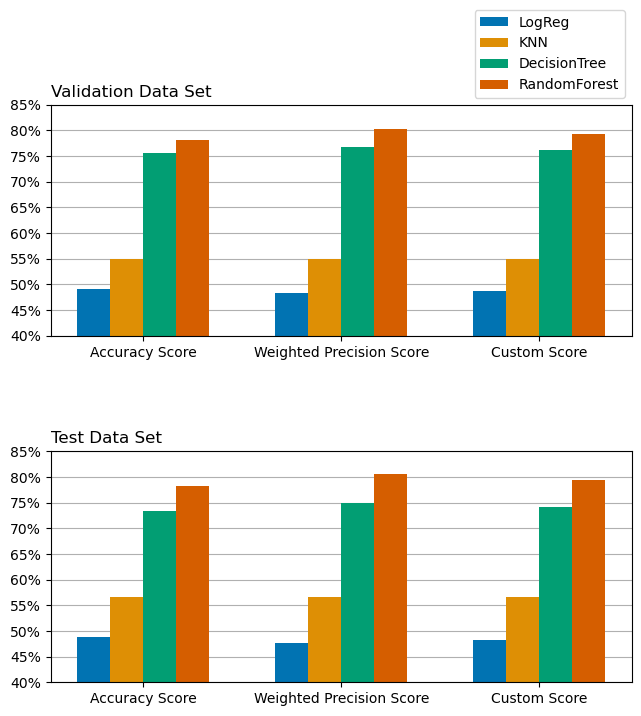

In [132]:
color_pal = sns.color_palette("colorblind")
fig = plt.figure(figsize = (7.5, 7.5))
axes = fig.subplots(2,1, gridspec_kw  ={'hspace':0.5})
x_labels = []
score_key = ['Validation', 'Test']

for m, ax in enumerate(axes):
    j = 0
    i = 0
    for model in po_list:
        dic = model.score_dic
        k = 0.25 + j
        for key in list(dic.keys()):

            if key not in x_labels:
                x_labels.append(key)

            bar_val = model.score_dic[key][score_key[m]]
            ax.bar(k, bar_val, width = 0.25, color = color_pal[i], label = model.model_name)
            k += 1.5

        j += 0.25
        i += 1
    
    ax.set_axisbelow(True)
    ax.grid(axis = 'y', zorder = 0)
    x_ticks = np.arange(0.625, 4, 1.5)
    ax.set_xticks(x_ticks, x_labels);
    y_ticks = np.arange(0, 1, 0.05)
    y_labels = ['{:.0%}'.format(i) for i in y_ticks]
    ax.set_yticks(y_ticks, y_labels)
    ax.set_ylim([0.40, 0.85])
    ax.set_title(f'{score_key[m]} Data Set', loc = 'left')
    
# Legend based on axes[0]
h, l = axes[0].get_legend_handles_labels()
new_l = [l[i] for i in np.arange(0, 10, 3)]
new_h = [h[i] for i in np.arange(0, 10, 3)]
axes[0].legend(new_h, new_l, loc = 'lower right', bbox_to_anchor=(1,1))    

fig.tight_layout()    
fig.savefig(r'slides/NB4_1.png', transparent = True, dpi = 800)
plt.show()

Accuracy Score 0.4877641824249166
Weighted Precision Score 0.47575143848889284
Accuracy Score 0.5656284760845384
Weighted Precision Score 0.5670132206822865
Accuracy Score 0.7341490545050056
Weighted Precision Score 0.7489603530644916
Accuracy Score 0.7814238042269188
Weighted Precision Score 0.8048167309580389


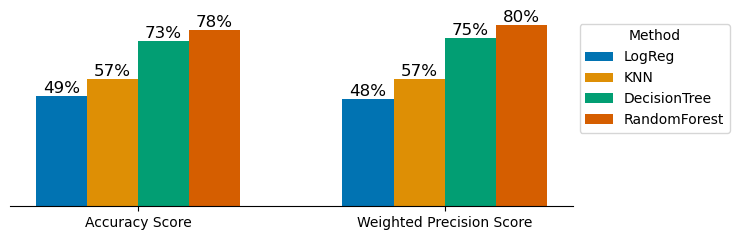

In [131]:
color_pal = sns.color_palette("colorblind")
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.subplots(1,1)
x_labels = []
score_key = ['Validation', 'Test']


j = 0
i = 0
for model in po_list:
    dic = model.score_dic
    k = 0.25 + j
    for key in list(dic.keys())[:2]:

        if key not in x_labels:
            x_labels.append(key)
        
        
        bar_val = model.score_dic[key]['Test']
        print(key, bar_val)
        ax.bar(k, bar_val, width = 0.25, color = color_pal[i], label = model.model_name)
        
        text = '{:.0%}'.format(bar_val)
        ax.text(k, bar_val + 0.0005, text, fontsize = 'large', horizontalalignment='center', verticalalignment='bottom') 
        k += 1.5

    j += 0.25
    i += 1

ax.set_axisbelow(True)
#ax.grid(axis = 'y', zorder = 0)
x_ticks = np.arange(0.625, 3, 1.5)
ax.set_xticks(x_ticks, x_labels);
y_ticks = np.arange(0, 1, 0.05)
y_labels = ['{:.0%}'.format(i) for i in y_ticks]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([], [])
#ax.set_yticks(y_ticks, y_labels)
#ax.set_ylim([0.40, 0.92])
#ax.set_title(f'{score_key[m]} Data Set', loc = 'left')

# Legend based on axes[0]
h, l = axes[0].get_legend_handles_labels()
new_l = [l[i] for i in np.arange(0, 10, 3)]
new_h = [h[i] for i in np.arange(0, 10, 3)]
ax.legend(new_h, new_l, title= 'Method', loc = 'lower left', bbox_to_anchor=(1,.35))    

fig.tight_layout()
fig.savefig('test_data_cava.png', transparent = True, dpi = 800)
plt.show()

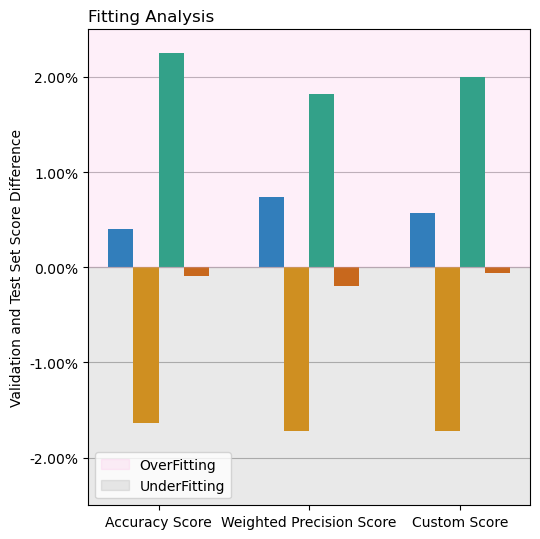

In [133]:
color_pal = sns.color_palette("colorblind")
fig = plt.figure(figsize = (5.5, 5.5))
ax = fig.subplots(1,1)
x_labels = []

j = 0
i = 0
for model in po_list:
    dic = model.score_dic
    k = 0.25 + j
    for key in list(dic.keys()):

        if key not in x_labels:
            x_labels.append(key)

        bar_val = model.score_dic[key]['Validation'] - model.score_dic[key]['Test']
        ax.bar(k, bar_val, width = 0.25, color = color_pal[i], label = model.model_name)
        k += 1.5

    j += 0.25
    i += 1

# Fill Between
x = np.arange(-1, k, 1)
y1 = np.zeros(x.shape[0])
over_y2 = [1]*x.shape[0]
under_y2 = [-1]*x.shape[0]

ax.fill_between(x, y1, over_y2, alpha = 0.2, color = color_pal[i+2], label = 'OverFitting')
ax.fill_between(x, y1, under_y2, alpha = 0.2, color = color_pal[i+3], label = 'UnderFitting')


# Setting Parameters
ax.set_axisbelow(True)
ax.grid(axis = 'y', zorder = 0)
x_ticks = np.arange(0.625, 4, 1.5)
ax.set_xticks(x_ticks, x_labels);
ax.set_xlim(-0.07500000000000001, 4.325)

y_ticks = np.arange(-0.04, 0.04, 0.01)
y_labels = ['{:.2%}'.format(i) for i in y_ticks]
ax.set_yticks(y_ticks, y_labels)
ax.set_ylim([-0.025, 0.025])
ax.set_title('Fitting Analysis', loc = 'left')
ax.set_ylabel(f'Validation and Test Set Score Difference')

# Adding Legend
h, l = ax.get_legend_handles_labels()
ax.legend(h[:2], l[:2])  

fig.tight_layout()
fig.savefig(r'slides/NB4_2.png', transparent = True, dpi = 800)
plt.show()

Based on the results, we conclude that the models were not able to achieve high levels of accuracy or precision, with the maximum score being 56%. Because the weighted precision and accuracy scores aligned with the results obtained from the custom score, we can confirm that the custom score was able to treat accuracy and precision equally.

Most of the scores were under fitted, indicating that the models did not capture the complexity of the data. Although, because the differences between the validation and precision scores were all within 1.05%, we can't definitively conclude that any model grossly over or under fitted another.   

In terms of performance, overall, the decision tree and random forest models outperformed Logistic Regression and KNN models. These results suggest that the relationship between the features and the target column is nonlinear, making decision trees or random forests the more ideal candidate for classifying the observations. Additionally, Random Forest demonstrated higher accuracy than Decision Trees, with an improvement of 0.96-3.7% across scores. The improved scores random forest demonstrated over decision trees is likely a consequence of its ability to handle high-dimensional data with many features without being as sensitive outliers as decision trees.

----

# Conclusion

In this notebook, we aimed to evaluate the effectiveness of different classification models in classifying citation entries based on author metrics. The custom scoring function used for evaluation weighted accuracy and precision equally to ensure that the model correctly classified the most citations while also minimizing false positives. The results of the individual grid searches indicated that the custom scoring function was able to successfully maintain an equal balance between weighted precision and accuracy when finding the best parameters. Unfortunately, the models did not achieve high levels of accuracy or precision, with the maximum score being 56%. However, the decision tree and random forest models outperformed logistic regression and KNN models in terms of performance, with random forest demonstrating higher accuracy than decision trees. These findings suggest that the relationship between the features and the target column requires separation by more than one boundary.. Based on the right skewed distribution of feature values and overlapping entries in tiers seen and discussed in **Notebook 3**, further feature engineering is needed to increase the accuracy of the classification. Moreover, future studies should include more robust exploratory data analysis into the data set to identify outliers to attempt to increase the general accuracy of the classification models. This additional feature engineering could include, but not be limited to:

- Using clustering methods to more accurately group entries by prestige 
- Feature Engineer additional predictive columns.